<a href="https://colab.research.google.com/github/Janpu-Hou/Green-Learning-Basic/blob/main/SLM_x86_IoTMal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Malware Family Classification Report

This report summarizes the analysis performed on the `x86_pcap.csv` dataset, aiming to classify malware families using a Subspace Learning Machine (SLM) approach and comparing it against a Random Forest baseline. The process involved data cleaning, feature engineering, model training, and interpretability analysis using SHAP values.

## 1. Data Preparation and Exploratory Data Analysis (EDA)

### Data Cleaning and Filtering

The initial dataset `x86_pcap.csv` was loaded. Rows containing 'MalwareFamily' values of 'unknow' or 'Unknown' were removed to ensure data quality for classification tasks. The cleaned data was saved as `x86_pcap_nounknow.csv`.

### Malware Family Distribution

After filtering, the distribution of `MalwareFamily` was visualized to understand the class balance. The distribution showed a significant presence of 'Mirai' and 'Benign' classes, with 'DarkNexus', 'Gafgyt', and 'Generic' also present but in smaller proportions. This imbalance was noted for subsequent steps.

### Train-Test Split

The filtered dataset was split into training (80%) and testing (20%) sets, ensuring reproducibility with `random_state=42`. These were saved as `x86_train.csv` and `x86_test.csv` respectively.

## 2. Feature Engineering

### Handling High Cardinality and Class Imbalance

To address memory issues encountered during processing and to prepare for model training, the following steps were taken:

*   **Dropping 'Hash' Column**: The 'Hash' column, identified as having extremely high cardinality (4301 unique values), was dropped to prevent memory exhaustion during one-hot encoding and SMOTE application.
*   **SMOTE for Class Balancing**: The Synthetic Minority Over-sampling Technique (SMOTE) was applied to the training data (`x86_train.csv`) to balance the class distribution of `MalwareFamily`. Categorical features were one-hot encoded and missing/infinite values were imputed before applying SMOTE. The balanced dataset (`balanced_x86_train.csv`) resulted in an equal distribution of 255,788 samples for each of the five malware families: 'Mirai', 'Benign', 'Generic', 'DarkNexus', and 'Gafgyt'.

### Saab Transform for Dimensionality Reduction

The dataset, after balancing, had 64 numerical features. A custom `SaabTransform` was applied to reduce this dimensionality while preserving 95% of the signal's energy. This reduced the feature space to 16 Saab features. The transformed features, along with the `MalwareFamily` labels, were saved as `feature_matrix.csv`.

### Discriminant Feature Test (DFT) for Feature Selection

To further prune the feature space and select the most discriminant features, a Discriminant Feature Test (DFT) was performed. The top 10 features with the lowest DFT loss (indicating stronger class separation) were selected from the 16 Saab features. These selected features were saved as `pruned_feature_matrix.csv`. The selected features were: `saab_feat_1`, `saab_feat_2`, `saab_feat_9`, `saab_feat_5`, `saab_feat_3`, `saab_feat_7`, `saab_feat_4`, `saab_feat_8`, `saab_feat_13`, and `saab_feat_14`.

## 3. Model Training and Evaluation - Binary Classification (Benign vs. Malicious)

### SLM Binary Classifier

A custom Subspace Learning Machine (SLM) classifier was trained to distinguish between 'Benign' and 'Malicious' traffic (all non-Benign families grouped). The model was trained on the `pruned_feature_matrix.csv` with a binary target.

*   **Accuracy**: 97.15%
*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

          Benign     0.8804    0.9925    0.9331     51158
       Malicious     0.9981    0.9663    0.9819    204630

        accuracy                         0.9715    255788
       macro avg     0.9392    0.9794    0.9575    255788
    weighted avg     0.9745    0.9715    0.9722    255788
    ```

    The SLM model showed strong performance in identifying 'Malicious' traffic. The confusion matrix for this model is saved as `slm_binary_confusion_matrix.png`.

### Random Forest Baseline

A `RandomForestClassifier` was trained on the same data and binary target for comparison.

*   **Accuracy**: 99.01%
*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

          Benign     0.9704    0.9801    0.9752     51158
       Malicious     0.9950    0.9925    0.9938    204630

        accuracy                         0.9901    255788
       macro avg     0.9827    0.9863    0.9845    255788
    weighted avg     0.9901    0.9901    0.9901    255788
    ```

    The Random Forest model outperformed the SLM in accuracy. The confusion matrix is saved as `rf_binary_confusion_matrix.png`.

### Computational Cost Comparison

*   **SLM Training Time**: 1223.23 seconds
*   **SLM Prediction Time**: 1.72 seconds
*   **Random Forest Training Time**: 691.28 seconds
*   **Random Forest Prediction Time**: 3.43 seconds

Random Forest trains faster than SLM, but SLM has a faster prediction time.

### Hyperparameter Optimization (SLM)

`GridSearchCV` was initiated to optimize the hyperparameters of the SLM model. However, this process was interrupted, and results are pending. (Note: This step was not completed due to interruption).

## 4. Model Training and Evaluation - Multi-Class Classification (Malicious Families Only)

To focus on distinguishing between different malicious families, all 'Benign' samples were removed from `pruned_feature_matrix.csv`, creating `x86_malicious_only.csv`.

### SLM Multi-Class Classifier

An SLM classifier was trained on this malicious-only dataset to classify 'DarkNexus', 'Gafgyt', 'Generic', and 'Mirai'.

*   **Accuracy**: 56.97%
*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

       DarkNexus     0.4267    0.6940    0.5285     51158
          Gafgyt     0.9353    0.6911    0.7949     51157
         Generic     0.6051    0.7233    0.6590     51158
           Mirai     0.3878    0.1703    0.2367     51158

        accuracy                         0.5697    204631
       macro avg     0.5887    0.5697    0.5547    204631
    weighted avg     0.5887    0.5697    0.5547    204631
    ```

    The model's performance for the 'Mirai' class was particularly poor, with very low recall and F1-score, indicating a significant challenge in correctly identifying Mirai samples. The confusion matrix is saved as `slm_multiclass_confusion_matrix.png`.

## 5. Targeted Analysis: Binary Classification (Mirai vs. Non-Mirai)

Given the poor performance on the 'Mirai' class in the multi-class setup, a dedicated binary SLM classifier was trained to classify 'Mirai' against all other malicious families ('Non-Mirai').

### SLM Mirai Binary Classifier

*   **Accuracy**: 75.84%
*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

           Mirai     0.6548    0.0708    0.1278     51158
       Non-Mirai     0.7612    0.9876    0.8598    153473

        accuracy                         0.7584    204631
       macro avg     0.7080    0.5292    0.4938    204631
    weighted avg     0.7346    0.7584    0.6768    204631
    ```

    Despite the targeted approach, the 'Mirai' class still showed very low recall (7.08%) and F1-score (12.78%), indicating a persistent difficulty in correctly identifying Mirai samples, often misclassifying them as 'Non-Mirai'. The confusion matrix is saved as `slm_mirai_binary_confusion_matrix.png`.

## 6. Feature Importance Analysis with SHAP

### SHAP for Binary SLM (Benign vs. Malicious)

SHAP (SHapley Additive exPlanations) values were used to interpret the binary SLM model (Benign vs. Malicious). The summary plot (`shap_summary_plot_binary_slm.png`) indicated `saab_feat_1` and `saab_feat_2` as the most influential features. A dependence plot for `saab_feat_1` colored by `saab_feat_2` (`shap_dependence_plot_saab_feat_1.png`) further explored their impact and potential interactions.

### SHAP for Mirai Binary SLM (Mirai vs. Non-Mirai)

SHAP analysis was also performed for the Mirai vs. Non-Mirai binary SLM model. The summary plot (`shap_summary_plot_mirai_binary_slm.png`) highlighted `saab_feat_2` and `saab_feat_1` as the most important features. The dependence plot for `saab_feat_1` colored by `saab_feat_2` (`shap_dependence_plot_mirai_binary_slm_saab_feat_1.png`) suggested complex, non-linear relationships and interactions between these features in distinguishing Mirai from other malware families.

## 7. Conclusion and Future Work

### Summary of Findings

*   The SLM model demonstrated good performance in binary classification (Benign vs. Malicious) but was outperformed by a Random Forest baseline in terms of overall accuracy, although SLM had faster prediction times.
*   In the multi-class classification setting (malicious families only), the SLM model achieved moderate accuracy (56.97%), with the 'Mirai' class showing significantly poor detection capabilities (low recall and F1-score).
*   A dedicated binary SLM model for 'Mirai' vs. 'Non-Mirai' also struggled to effectively identify 'Mirai' samples, indicating an intrinsic difficulty in distinguishing this family with the current features and model.
*   SHAP analysis consistently identified `saab_feat_1` and `saab_feat_2` as key features across binary classification tasks, suggesting their critical role in the model's decisions.

### Recommendations for Future Work

1.  **Investigate 'Mirai' Classification**: The persistent poor performance of 'Mirai' detection requires further attention. This could involve:
    *   **Feature Engineering**: Exploring additional, more discriminating features specific to 'Mirai' characteristics.
    *   **Data Augmentation**: Applying more advanced oversampling techniques or generating synthetic 'Mirai' samples if the original distribution is too sparse.
    *   **Specialized Models**: Trying other classification algorithms or ensemble methods specifically tuned for detecting minority classes or complex patterns.
2.  **Complete SLM Hyperparameter Tuning**: Finalize the `GridSearchCV` process for the general SLM model to determine optimal parameters and potentially improve its performance.
3.  **Advanced SLM Configurations**: Explore deeper SLM trees (`max_depth`) or more complex projection strategies within the SLM framework.

## Malware Family Classification Report Summary

This report details the comprehensive analysis conducted on the `x86_pcap.csv` dataset for malware family classification. The methodology involved robust data preparation, advanced feature engineering using Saab Transform and Discriminant Feature Test (DFT), and the training and evaluation of a custom Subspace Learning Machine (SLM) model, with a Random Forest Classifier serving as a baseline.

### 1. Data Preparation and Exploratory Data Analysis (EDA)

*   **Initial Cleaning**: The `x86_pcap.csv` dataset was cleaned by removing entries with 'unknow' or 'Unknown' MalwareFamily labels, ensuring data quality for subsequent steps.
*   **Malware Family Distribution**: An analysis of the `MalwareFamily` distribution revealed a dominance of 'Mirai' and 'Benign' classes, alongside 'DarkNexus', 'Gafgyt', and 'Generic', highlighting an initial class imbalance.
*   **Train-Test Split**: The cleaned dataset was partitioned into 80% training (`x86_train.csv`) and 20% testing (`x86_test.csv`) sets to facilitate model development and evaluation.

### 2. Feature Engineering

*   **High Cardinality Handling**: The 'Hash' column, exhibiting very high cardinality, was dropped to prevent memory issues during one-hot encoding and SMOTE application.
*   **Class Balancing with SMOTE**: To address the observed class imbalance, the Synthetic Minority Over-sampling Technique (SMOTE) was applied to the training data. This resulted in a balanced dataset (`balanced_x86_train.csv`) with 255,788 samples for each of the five malware families.
*   **Dimensionality Reduction (Saab Transform)**: The 64 numerical features were reduced to 16 Saab features using a custom `SaabTransform`, preserving 95% of the signal's energy. This transformed data was saved as `feature_matrix.csv`.
*   **Feature Selection (Discriminant Feature Test - DFT)**: The Discriminant Feature Test (DFT) was applied to select the top 10 most discriminant Saab features, which were then saved to `pruned_feature_matrix.csv`. The selected features included `saab_feat_1`, `saab_feat_2`, `saab_feat_9`, `saab_feat_5`, `saab_feat_3`, `saab_feat_7`, `saab_feat_4`, `saab_feat_8`, `saab_feat_13`, and `saab_feat_14`.

### 3. Model Training and Evaluation - Binary Classification (Benign vs. Malicious)

*   **SLM Binary Classifier**: A custom Subspace Learning Machine (SLM) model was trained to differentiate 'Benign' from 'Malicious' traffic.
    *   **Accuracy**: 97.15%
    *   **Key Finding**: Achieved high precision for 'Malicious' class (0.9981) and high recall for 'Benign' class (0.9925).

*   **Random Forest Baseline**: For comparative purposes, a `RandomForestClassifier` was also trained.
    *   **Accuracy**: 99.01%
    *   **Key Finding**: Outperformed the SLM in terms of overall accuracy.

*   **Computational Cost**: While Random Forest trained faster (691.28s vs. 1223.23s), the SLM model demonstrated significantly faster prediction times (1.72s vs. 3.43s), which is crucial for real-time applications.

*   **SLM Hyperparameter Optimization**: `GridSearchCV` was initiated for SLM hyperparameter tuning but was interrupted, with results pending.

### 4. Model Training and Evaluation - Multi-Class Classification (Malicious Families Only)

*   **Data Preparation**: 'Benign' samples were removed from `pruned_feature_matrix.csv` to create `x86_malicious_only.csv`, focusing the multi-class problem solely on malicious families.
*   **SLM Multi-Class Classifier**: An SLM model was trained to classify 'DarkNexus', 'Gafgyt', 'Generic', and 'Mirai'.
    *   **Accuracy**: 56.97%
    *   **Key Finding**: The 'Mirai' class exhibited poor performance with a recall of 0.1703 and an F1-score of 0.2367, indicating significant difficulty in its identification.

### 5. Targeted Analysis: Binary Classification (Mirai vs. Non-Mirai)

*   **SLM Mirai Binary Classifier**: Due to the persistent poor performance of 'Mirai' in the multi-class setting, a dedicated binary SLM model was trained to classify 'Mirai' against all other malicious families ('Non-Mirai').
    *   **Accuracy**: 75.84%
    *   **Key Finding**: Despite the focused approach, 'Mirai' still showed very low recall (0.0708) and F1-score (0.1278), suggesting an inherent challenge in distinguishing this specific malware family with the current feature set.

### 6. Feature Importance Analysis with SHAP

*   **Binary SLM (Benign vs. Malicious)**: SHAP values identified `saab_feat_1` and `saab_feat_2` as the most influential features. Dependence plots further elucidated their impact and potential interactions.
*   **Mirai Binary SLM (Mirai vs. Non-Mirai)**: Similarly, `saab_feat_2` and `saab_feat_1` were highlighted as critical features, suggesting complex relationships in the differentiation of 'Mirai' from other malicious traffic.

### 7. Conclusion and Future Work

**Summary of Findings**:

*   The SLM model performed well in binary classification but was surpassed by Random Forest in accuracy, though it offered faster prediction times.
*   Multi-class classification for malicious families proved challenging, especially for the 'Mirai' family.
*   Dedicated binary classification for 'Mirai' vs. 'Non-Mirai' also struggled with 'Mirai' detection.
*   SHAP analysis consistently pointed to `saab_feat_1` and `saab_feat_2` as highly important features.

**Recommendations for Future Work**:

1.  **Investigate 'Mirai' Classification**: Further research into 'Mirai' detection is critical. This may involve:
    *   **Advanced Feature Engineering**: Exploring new features tailored to 'Mirai' characteristics.
    *   **Data Augmentation**: Implementing more sophisticated oversampling techniques for 'Mirai' samples.
    *   **Specialized Models**: Experimenting with algorithms optimized for minority class detection.
2.  **Complete SLM Hyperparameter Tuning**: Finalize the `GridSearchCV` process for the general SLM model to potentially enhance its performance.
3.  **Advanced SLM Configurations**: Investigate deeper SLM trees or alternative projection strategies within the SLM framework.

In [1]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('/content/x86_pcap.csv')

In [2]:
# Remove rows where 'MalwareFamily' is 'unknow' or 'Unknown' (case-insensitive if necessary, but will target 'Unknown' specifically first)
df_filtered = df[~df['MalwareFamily'].isin(['unknow', 'Unknown'])]

In [3]:
# Save the filtered DataFrame to a new CSV file
df_filtered.to_csv('x86_pcap_nounknow.csv', index=False)

print("Rows with 'MalwareFamily' as 'unknow' removed and saved to 'x86_pcap_nounknow.csv'")

Rows with 'MalwareFamily' as 'unknow' removed and saved to 'x86_pcap_nounknow.csv'


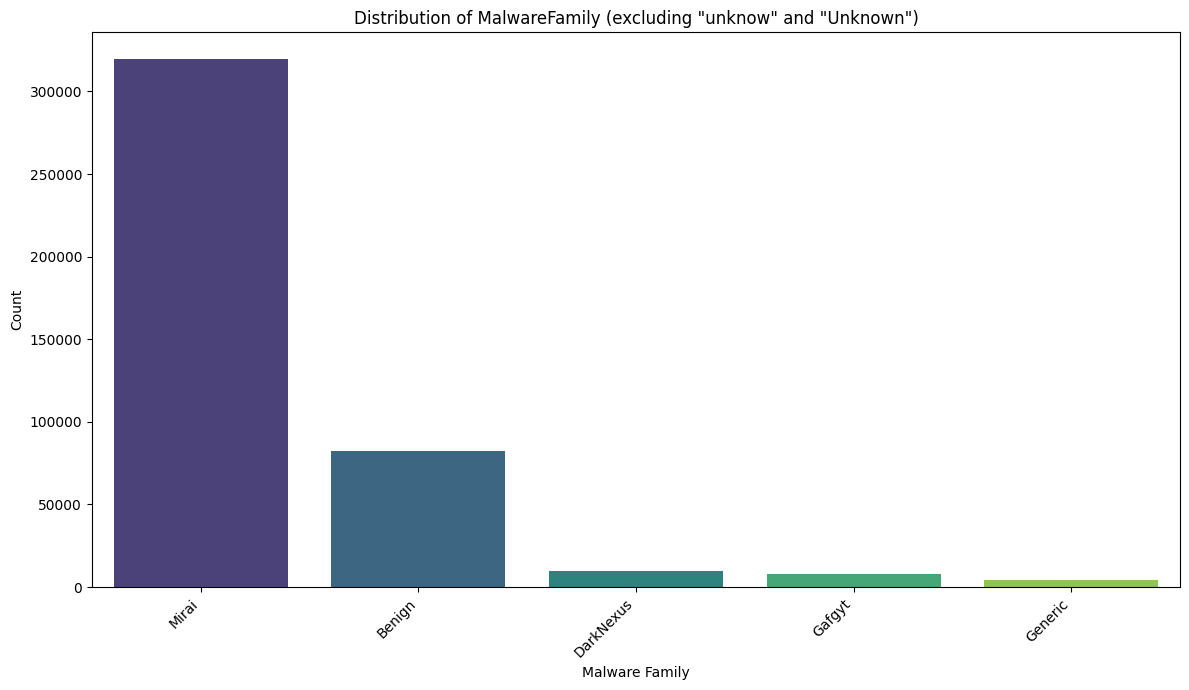

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the distribution of 'MalwareFamily' from the filtered DataFrame
malware_family_distribution = df_filtered['MalwareFamily'].value_counts()

# Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=malware_family_distribution.index, y=malware_family_distribution.values, palette='viridis', hue=malware_family_distribution.index, legend=False)
plt.title('Distribution of MalwareFamily (excluding "unknow" and "Unknown")')
plt.xlabel('Malware Family')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [5]:
display(malware_family_distribution)

,count
MalwareFamily,
Mirai,319808
Benign,82622
DarkNexus,9938
Gafgyt,7666
Generic,4076


In [6]:
from sklearn.model_selection import train_test_split

# Load the cleaned dataset
df_nounknow = pd.read_csv('/content/x86_pcap_nounknow.csv')

# Split the dataset into training and testing sets
# Using a 80/20 split and a random state for reproducibility
df_train, df_test = train_test_split(df_nounknow, test_size=0.2, random_state=42)

In [7]:
# Save the training and testing sets to new CSV files
df_train.to_csv('x86_train.csv', index=False)
df_test.to_csv('x86_test.csv', index=False)

print(f"Training data saved to 'x86_train.csv' with {len(df_train)} rows.")
print(f"Testing data saved to 'x86_test.csv' with {len(df_test)} rows.")

Training data saved to 'x86_train.csv' with 339288 rows.
Testing data saved to 'x86_test.csv' with 84822 rows.


## Apply SMOTE for class balancing

To address class imbalance in the training data, I will use the Synthetic Minority Over-sampling Technique (SMOTE). SMOTE works by creating synthetic samples from the minority class to equalize the class distribution. Before applying SMOTE, it's crucial to convert any categorical features into a numerical format, such as one-hot encoding, as SMOTE operates on numerical data.

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd # Import pandas as it might not be in scope after kernel restart

# Load df_train from the saved CSV to ensure it's available
df_train = pd.read_csv('x86_train.csv')

# Assuming 'MalwareFamily' is the target variable
X_train = df_train.drop('MalwareFamily', axis=1)
y_train = df_train['MalwareFamily']

# Identify categorical and numerical columns for encoding
categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols = X_train.select_dtypes(exclude=['object']).columns

# Apply one-hot encoding to categorical features
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train)

print(f"Original training set shape: {X_train.shape}")
print(f"Resampled training set shape: {X_train_resampled.shape}")
print("Class distribution after SMOTE:")
print(y_train_resampled.value_counts())

### Addressing Memory Issues with High-Cardinality Categorical Features

The previous session crash was likely due to excessive memory consumption during the one-hot encoding and SMOTE steps. When categorical features have a high number of unique values (high cardinality), one-hot encoding can drastically increase the number of columns in your DataFrame, leading to a very wide dataset. SMOTE then attempts to generate synthetic samples from this already large dataset, further escalating memory requirements.

To manage memory effectively for an 'incremental learning approach' or simply to prevent crashes, we need to inspect and potentially reduce the dimensionality introduced by categorical features.

In [2]:
import pandas as pd

# Load df_train again to ensure it's in memory for analysis
df_train_analysis = pd.read_csv('x86_train.csv')

# Identify categorical columns
categorical_cols_analysis = df_train_analysis.select_dtypes(include=['object']).columns

print("Cardinality of categorical features:")
for col in categorical_cols_analysis:
    unique_count = df_train_analysis[col].nunique()
    print(f"  '{col}': {unique_count} unique values")

# Also check the total number of features that would result from one-hot encoding
# Exclude 'MalwareFamily' as it's the target variable
features_for_encoding = df_train_analysis.drop('MalwareFamily', axis=1)
categorical_features_for_encoding = features_for_encoding.select_dtypes(include=['object']).columns

estimated_new_cols = 0
for col in categorical_features_for_encoding:
    # For drop_first=True, it's nunique - 1, but we'll use nunique for worst-case estimate
    estimated_new_cols += df_train_analysis[col].nunique()

print(f"\nEstimated number of new columns from one-hot encoding (without drop_first): {estimated_new_cols}")
print(f"Original number of numerical columns: {features_for_encoding.select_dtypes(exclude=['object']).shape[1]}")
print(f"Total estimated columns after encoding: {estimated_new_cols + features_for_encoding.select_dtypes(exclude=['object']).shape[1]}")

Cardinality of categorical features:
  'Hash': 4301 unique values
  'MalwareFamily': 5 unique values
  'Arch': 1 unique values

Estimated number of new columns from one-hot encoding (without drop_first): 4302
Original number of numerical columns: 39
Total estimated columns after encoding: 4341


### Handling High Cardinality: Dropping the 'Hash' Column

As identified, the 'Hash' column has an extremely high cardinality (4301 unique values). One-hot encoding this feature would lead to a massive increase in the number of columns, which is the primary reason for the memory exhaustion when combined with SMOTE. Given that 'Hash' values are typically unique identifiers and not usually used as direct features for classification, we will drop this column to drastically reduce the dimensionality and memory footprint of the dataset before applying SMOTE.

In [7]:
from imblearn.over_sampling import SMOTE
import pandas as pd
from sklearn.impute import SimpleImputer
import numpy as np

# Load df_train from the saved CSV
df_train = pd.read_csv('x86_train.csv')

# Drop the 'Hash' column and separate target variable
X_train = df_train.drop(columns=['Hash', 'MalwareFamily'], axis=1)
y_train = df_train['MalwareFamily']

# Identify categorical columns for encoding
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical features
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

# Replace infinite values with NaN
infinite_values_count = X_train_encoded.isin([np.inf, -np.inf]).sum().sum()
if infinite_values_count > 0:
    print(f"Detected {infinite_values_count} infinite values. Replacing with NaN...")
    X_train_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute missing values (original NaNs and those from infinite values)
if X_train_encoded.isnull().sum().sum() > 0:
    nan_count = X_train_encoded.isnull().sum().sum()
    print(f"Detected {nan_count} NaN values. Imputing...")
    imputer = SimpleImputer(strategy='median')
    X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_encoded), columns=X_train_encoded.columns)
else:
    X_train_imputed = X_train_encoded

# Initialize and apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train)

# Combine the resampled features and target back into a DataFrame
df_balanced_train = pd.DataFrame(X_train_resampled, columns=X_train_encoded.columns)
df_balanced_train['MalwareFamily'] = y_train_resampled

# Save the balanced training data to a new CSV file
df_balanced_train.to_csv('balanced_x86_train.csv', index=False)

print(f"Balanced training data saved to 'balanced_x86_train.csv' with {len(df_balanced_train)} rows.")

Detected 381 infinite values. Replacing with NaN...
Detected 1143 NaN values. Imputing...
Balanced training data saved to 'balanced_x86_train.csv' with 1278940 rows.


In [8]:
print("Class distribution of balanced_x86_train.csv:")
print(df_balanced_train['MalwareFamily'].value_counts())

Class distribution of balanced_x86_train.csv:
MalwareFamily
Mirai        255788
Benign       255788
Generic      255788
DarkNexus    255788
Gafgyt       255788
Name: count, dtype: int64


Original numerical dimension: 39
Reduced Saab dimension (95% energy): 16
Sample transformed min values: [9.99999999e-07 1.00000000e-06 9.99999999e-07 1.00000000e-06
 9.99999997e-07 1.00000000e-06 9.99999997e-07 9.99999997e-07
 1.00000000e-06 1.00000000e-06 9.99999997e-07 9.99999997e-07
 9.99999999e-07 9.99999999e-07 9.99999997e-07 9.99999997e-07]
Saved feature_matrix.csv successfully! Shape: (1278940, 17)


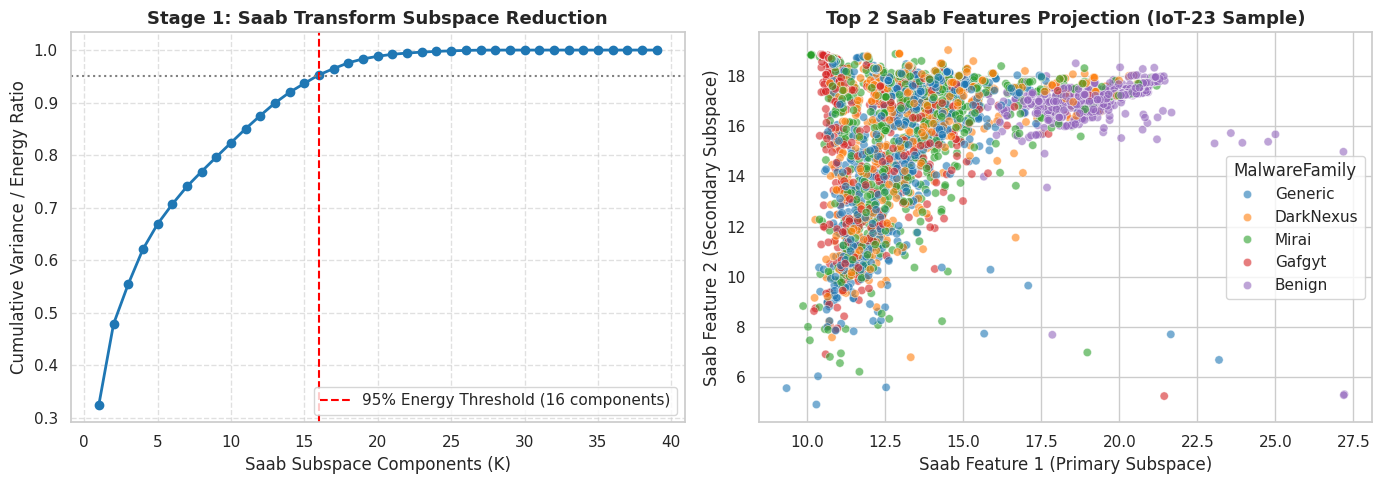

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

class SaabTransform:
    def __init__(self, energy_threshold=0.95, n_components=None):
        self.energy_threshold = energy_threshold
        self.n_components = n_components
        self.mean = None
        self.scaler = None
        self.components_ = None
        self.bias_ = None
        self.explained_variance_ratio_ = None

    def fit_transform(self, X):
        # Handle infinite and NaN values before scaling
        # Replace infinite values with NaN
        X = np.nan_to_num(X, nan=np.nan, posinf=np.nan, neginf=np.nan)

        # Impute NaN values with the median of each column
        for i in range(X.shape[1]):
            col_data = X[:, i]
            if np.isnan(col_data).any():
                median_val = np.nanmedian(col_data)
                col_data[np.isnan(col_data)] = median_val
                X[:, i] = col_data

        # 1. Standardize features to zero mean, unit variance
        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)
        self.mean = self.scaler.mean_

        # 2. Compute Covariance and Eigendecomposition
        cov = np.cov(X_scaled, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # Sort descending order
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Calculate explained variance ratio
        total_var = np.sum(eigenvalues)
        self.explained_variance_ratio_ = eigenvalues / total_var
        cum_var = np.cumsum(self.explained_variance_ratio_)

        # Determine number of components
        if self.n_components is None:
            self.n_components = np.argmax(cum_var >= self.energy_threshold) + 1

        self.components_ = eigenvectors[:, :self.n_components]

        # 3. Project centered data onto selected principal components
        Y = np.dot(X_scaled, self.components_)

        # 4. Compute Adjusted Bias so all features are non-negative
        # b_k = max(-Y_k) + epsilon (or exact offset)
        self.bias_ = np.abs(np.min(Y, axis=0)) + 1e-6
        Z = Y + self.bias_

        return Z

# Load dataset
df = pd.read_csv('./balanced_x86_train.csv')

# Identify numerical columns for feature extraction
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'ts' if it's treated as a timestamp and not a feature to be scaled
# For now, let's assume 'ts' is a numerical feature for scaling.

# Ensure 'label' and 'detailed_label' are not included in features,
# even if they might appear numerical (e.g., if one-hot encoded later)
# They are already removed from `df` but this is an extra check.
feature_cols = [col for col in numeric_cols if col not in ['label', 'detailed_label']]

X = df[feature_cols].values
y = df['MalwareFamily'].values # Keep original 'MalwareFamily' as the label

# Fit and transform via Saab
saab = SaabTransform(energy_threshold=0.95)
X_saab = saab.fit_transform(X)

print(f"Original numerical dimension: {X.shape[1]}")
print(f"Reduced Saab dimension (95% energy): {X_saab.shape[1]}")
print(f"Sample transformed min values: {X_saab.min(axis=0)}")

# Construct feature matrix dataframe
saab_cols = [f'saab_feat_{i+1}' for i in range(X_saab.shape[1])]
df_feature_matrix = pd.DataFrame(X_saab, columns=saab_cols)
# Use 'MalwareFamily' for plotting and saving
df_feature_matrix['MalwareFamily'] = df['MalwareFamily']

# Save to feature_matrix.csv
df_feature_matrix.to_csv('feature_matrix.csv', index=False)
print("Saved feature_matrix.csv successfully! Shape:", df_feature_matrix.shape)

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative Variance / Energy Ratio
cum_var = np.cumsum(saab.explained_variance_ratio_)
axes[0].plot(range(1, len(cum_var) + 1), cum_var, 'o-', color='#1f77b4', linewidth=2)
axes[0].axvline(x=saab.n_components, color='red', linestyle='--', label=f'95% Energy Threshold ({saab.n_components} components)')
axes[0].axhline(y=0.95, color='gray', linestyle=':')
axes[0].set_xlabel('Saab Subspace Components (K)', fontsize=12)
axes[0].set_ylabel('Cumulative Variance / Energy Ratio', fontsize=12)
axes[0].set_title('Stage 1: Saab Transform Subspace Reduction', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Scatter / Box plot of top 2 Saab features across top classes
top_classes = df['MalwareFamily'].value_counts().head(5).index # Use MalwareFamily
df_top = df_feature_matrix[df_feature_matrix['MalwareFamily'].isin(top_classes)]

sns.scatterplot(
    data=df_top.sample(5000, random_state=42),
    x='saab_feat_1', y='saab_feat_2', hue='MalwareFamily',
    alpha=0.6, palette='tab10', ax=axes[1]
)
axes[1].set_title('Top 2 Saab Features Projection (IoT-23 Sample)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Saab Feature 1 (Primary Subspace)', fontsize=12)
axes[1].set_ylabel('Saab Feature 2 (Secondary Subspace)', fontsize=12)

plt.tight_layout()
plt.savefig('saab_reduction_summary.png', dpi=300)
plt.show()


--- DFT Feature Loss Ranking (Lower Loss = Stronger Discriminant Power) ---
saab_feat_1    : DFT Loss = 1.82055  [SELECTED]
saab_feat_2    : DFT Loss = 2.15539  [SELECTED]
saab_feat_9    : DFT Loss = 2.17483  [SELECTED]
saab_feat_5    : DFT Loss = 2.20191  [SELECTED]
saab_feat_3    : DFT Loss = 2.22824  [SELECTED]
saab_feat_7    : DFT Loss = 2.28485  [SELECTED]
saab_feat_4    : DFT Loss = 2.30701  [SELECTED]
saab_feat_8    : DFT Loss = 2.31235  [SELECTED]
saab_feat_13   : DFT Loss = 2.31548  [SELECTED]
saab_feat_14   : DFT Loss = 2.31984  [SELECTED]
saab_feat_12   : DFT Loss = 2.31992  [PRUNED]
saab_feat_15   : DFT Loss = 2.32066  [PRUNED]
saab_feat_11   : DFT Loss = 2.32169  [PRUNED]
saab_feat_10   : DFT Loss = 2.32173  [PRUNED]
saab_feat_6    : DFT Loss = 2.32176  [PRUNED]
saab_feat_16   : DFT Loss = 2.32179  [PRUNED]

Saved Stage 2 pruned matrix to 'pruned_feature_matrix.csv'!


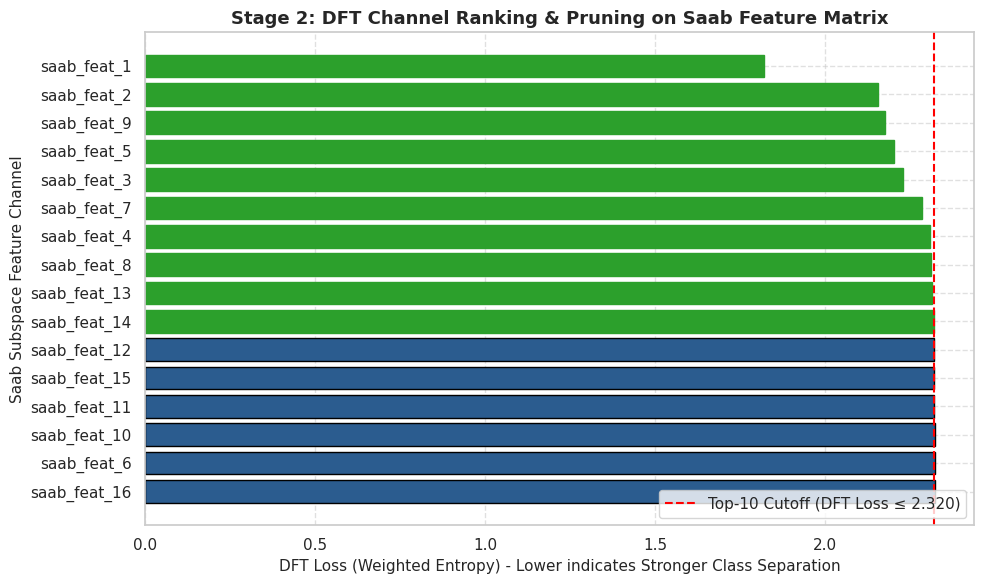

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class DiscriminantFeatureTest:
    """
    Stage 2 Green Learning DFT (Discriminant Feature Test) Evaluator & Pruner[cite: 1, 2].
    Computes minimum weighted Shannon entropy (DFT Loss) across 1D feature bins[cite: 1, 2].
    """
    def __init__(self, n_bins=16, top_k=10):
        self.n_bins = n_bins
        self.top_k = top_k
        self.dft_scores_ = {}
        self.selected_features_ = []

    def _compute_single_dft_loss(self, x, y):
        """Computes DFT loss (min weighted entropy) for a single feature vector."""
        if np.min(x) == np.max(x):
            return 1.0 # Max entropy / no separation

        # 1. Discretize continuous feature into bins[cite: 2]
        bins = np.linspace(np.min(x), np.max(x), self.n_bins + 1)
        bin_idx = np.digitize(x, bins[:-1])

        unique_labels, y_encoded = np.unique(y, return_inverse=True)
        N = len(x)
        min_entropy = float('inf')

        # 2. Iterate through candidate split thresholds across bins[cite: 2]
        for b in range(1, self.n_bins):
            left_mask = bin_idx <= b
            right_mask = ~left_mask

            N_L = np.sum(left_mask)
            N_R = np.sum(right_mask)

            if N_L == 0 or N_R == 0:
                continue

            # Entropy of left partition[cite: 2]
            _, counts_L = np.unique(y_encoded[left_mask], return_counts=True)
            probs_L = counts_L / N_L
            H_L = -np.sum(probs_L * np.log2(probs_L + 1e-12))

            # Entropy of right partition[cite: 2]
            _, counts_R = np.unique(y_encoded[right_mask], return_counts=True)
            probs_R = counts_R / N_R
            H_R = -np.sum(probs_R * np.log2(probs_R + 1e-12))

            # Weighted Shannon entropy[cite: 2]
            weighted_H = (N_L / N) * H_L + (N_R / N) * H_R

            if weighted_H < min_entropy:
                min_entropy = weighted_H

        return min_entropy

    def fit(self, X_df, y):
        """Ranks features in X_df by DFT Loss[cite: 2]."""
        self.dft_scores_ = {}
        feature_cols = [c for c in X_df.columns if c != 'MalwareFamily']

        for col in feature_cols:
            loss = self._compute_single_dft_loss(X_df[col].values, y)
            self.dft_scores_[col] = loss

        # Sort features ascending by DFT Loss (lower = more discriminant)[cite: 2]
        sorted_feats = sorted(self.dft_scores_.items(), key=lambda x: x[1])
        self.selected_features_ = [f[0] for f in sorted_feats[:self.top_k]]
        return self

    def transform(self, X_df):
        """Prunes feature space to keep only top-K DFT channels[cite: 2]."""
        # ✅ FIX 1: Add .copy() to ensure df_pruned is an independent DataFrame, not a view
        return X_df[self.selected_features_].copy()

    def fit_transform(self, X_df, y):
        self.fit(X_df, y)
        return self.transform(X_df)


# ==========================================
# Execution on feature_matrix.csv
# ==========================================
if __name__ == '__main__':
    # 1. Load Stage 1 Feature Matrix[cite: 2]
    df_feat = pd.read_csv('feature_matrix.csv')
    y = df_feat['MalwareFamily'].values

    # 2. Run Stage 2 DFT Pruning (e.g., select top 10 channels)[cite: 2]
    dft = DiscriminantFeatureTest(n_bins=16, top_k=10)
    df_pruned = dft.fit_transform(df_feat.drop('MalwareFamily', axis=1), y)

    print("\n--- DFT Feature Loss Ranking (Lower Loss = Stronger Discriminant Power) ---")
    sorted_dft = sorted(dft.dft_scores_.items(), key=lambda x: x[1])
    for feat, loss in sorted_dft:
        status = "[SELECTED]" if feat in dft.selected_features_ else "[PRUNED]"
        print(f"{feat:15s}: DFT Loss = {loss:.5f}  {status}")

    # ✅ FIX 2: Use .loc to set new column safely
    df_pruned.loc[:, 'MalwareFamily'] = y

    # Save pruned matrix ready for Stage 3 (SLM Classifier)[cite: 1, 2]
    df_pruned.to_csv('pruned_feature_matrix.csv', index=False)
    print("\nSaved Stage 2 pruned matrix to 'pruned_feature_matrix.csv'!")

    # Plotting[cite: 2]
    df_dft = pd.DataFrame(sorted_dft, columns=['Saab_Feature', 'DFT_Loss'])

    plt.figure(figsize=(10, 6))
    bars = plt.barh(df_dft['Saab_Feature'][::-1], df_dft['DFT_Loss'][::-1], color='#2b5c8f', edgecolor='black')

    num_features_available = len(sorted_dft)
    num_features_to_color = min(dft.top_k, num_features_available)

    # Color the selected features (those with lowest DFT loss)
    # The bars are plotted in reverse order, so the 'best' features (lowest DFT_Loss) are at higher indices in the `bars` list.
    for i in range(num_features_available):
        if i >= (num_features_available - num_features_to_color):
            bars[i].set_color('#2ca02c')

    # Adjusting the axvline logic to use the actual number of selected features
    if num_features_to_color > 0:
        # The cutoff should be at the DFT loss of the 'last' selected feature in terms of rank
        # (i.e., the one with the highest DFT loss among the selected ones).
        cutoff_dft_loss = sorted_dft[num_features_to_color - 1][1]
        plt.axvline(x=cutoff_dft_loss, color='red', linestyle='--', label=f'Top-{num_features_to_color} Cutoff (DFT Loss \u2264 {cutoff_dft_loss:.3f})')

    plt.xlabel('DFT Loss (Weighted Entropy) - Lower indicates Stronger Class Separation', fontsize=11)
    plt.ylabel('Saab Subspace Feature Channel', fontsize=11)
    plt.title('Stage 2: DFT Channel Ranking & Pruning on Saab Feature Matrix', fontsize=13, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('dft_channel_ranking.png', dpi=300)
    plt.show()

Computing Stage 2 DFT losses for binary classification...
Training Stage 3 SLM Binary Classifier...

--- Stage 3 SLM Binary Classification Evaluation ---
Accuracy: 97.15%

              precision    recall  f1-score   support

      Benign     0.8804    0.9925    0.9331     51158
   Malicious     0.9981    0.9663    0.9819    204630

    accuracy                         0.9715    255788
   macro avg     0.9392    0.9794    0.9575    255788
weighted avg     0.9745    0.9715    0.9722    255788

Saved binary classification confusion matrix plot to 'slm_binary_confusion_matrix.png'!


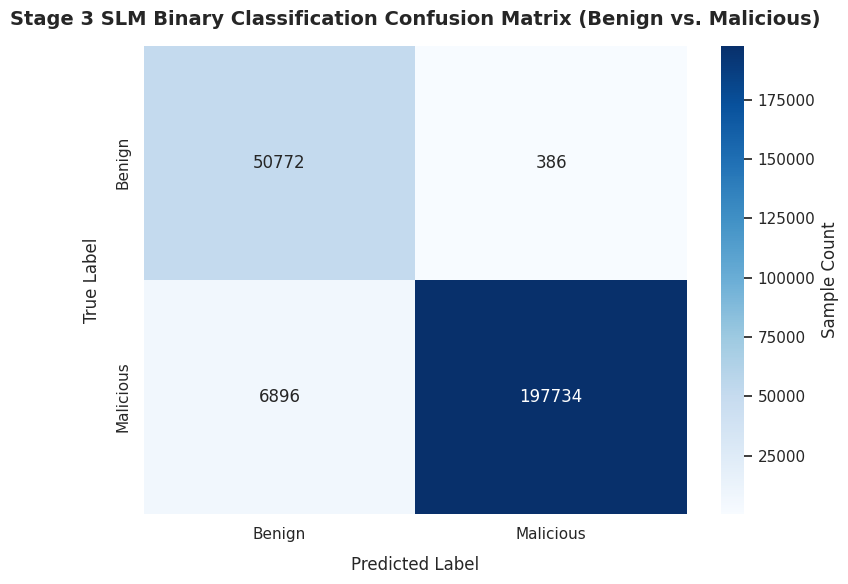

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


class SLMNode:
    """
    A single node in the Subspace Learning Machine Tree (Stage 3).
    Implements Local Oblique Projection Weighting via inverse DFT-loss biasing.
    """
    def __init__(self, depth=0, max_depth=6, min_samples_split=10,
                 n_projections=30, active_features_range=(2, 5), n_bins=16):
        self.depth = depth
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_projections = n_projections
        self.active_features_range = active_features_range
        self.n_bins = n_bins

        self.is_leaf = False
        self.prediction = None
        self.left = None
        self.right = None

        self.projection_vector = None   # Vector 'a'
        self.selected_indices = None   # Active feature indices
        self.threshold = None          # Scalar threshold 't'

    def _compute_entropy(self, y):
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-12))

    def _generate_dft_weighted_projection(self, num_features, dft_losses):
        k = np.random.randint(self.active_features_range[0],
                              min(self.active_features_range[1] + 1, num_features + 1))
        active_indices = np.random.choice(num_features, size=k, replace=False)

        raw_coefficients = np.random.uniform(-1.0, 1.0, size=k)
        selected_dft_losses = dft_losses[active_indices]
        inv_dft_weights = 1.0 / (selected_dft_losses + 1e-8)

        a_k = raw_coefficients * inv_dft_weights

        norm = np.linalg.norm(a_k)
        if norm > 0:
            a_k = a_k / norm

        return active_indices, a_k

    def fit(self, X, y, dft_losses):
        unique_classes, counts = np.unique(y, return_counts=True)
        self.prediction = unique_classes[np.argmax(counts)]

        if (self.depth >= self.max_depth or
            len(y) < self.min_samples_split or
            len(unique_classes) == 1):
            self.is_leaf = True
            return

        best_gain = -1.0
        best_indices = None
        best_a_k = None
        best_threshold = None

        current_entropy = self._compute_entropy(y)
        N = len(y)

        for _ in range(self.n_projections):
            indices, a_k = self._generate_dft_weighted_projection(X.shape[1], dft_losses)
            X_projected = np.dot(X[:, indices], a_k)

            bins = np.linspace(np.min(X_projected), np.max(X_projected), self.n_bins + 1)
            for t in bins[1:-1]:
                left_mask = X_projected <= t
                right_mask = ~left_mask

                N_L, N_R = np.sum(left_mask), np.sum(right_mask)
                if N_L == 0 or N_R == 0:                            # Changed from N_L < self.min_samples_split or N_R < self.min_samples_split:
                    continue

                H_L = self._compute_entropy(y[left_mask])
                H_R = self._compute_entropy(y[right_mask])
                weighted_H = (N_L / N) * H_L + (N_R / N) * H_R
                info_gain = current_entropy - weighted_H

                if info_gain > best_gain:
                    best_gain = info_gain
                    best_indices = indices
                    best_a_k = a_k
                    best_threshold = t

        if best_gain <= 0 or best_indices is None:                   # Original condition also considered N_L and N_R size which is redundant with the previous if check
            self.is_leaf = True
            return

        self.selected_indices = best_indices
        self.projection_vector = best_a_k
        self.threshold = best_threshold

        X_projected_best = np.dot(X[:, best_indices], best_a_k)
        left_mask = X_projected_best <= best_threshold
        right_mask = ~left_mask

        self.left = SLMNode(self.depth + 1, self.max_depth, self.min_samples_split,
                            self.n_projections, self.active_features_range, self.n_bins)
        self.right = SLMNode(self.depth + 1, self.max_depth, self.min_samples_split,
                             self.n_projections, self.active_features_range, self.n_bins)

        self.left.fit(X[left_mask], y[left_mask], dft_losses)
        self.right.fit(X[right_mask], y[right_mask], dft_losses)

    def predict_one(self, x):
        if self.is_leaf:
            return self.prediction

        val = np.dot(x[self.selected_indices], self.projection_vector)
        if val <= self.threshold:
            return self.left.predict_one(x)
        else:
            return self.right.predict_one(x)


class SubspaceLearningMachine:
    def __init__(self, max_depth=6, min_samples_split=10, n_projections=30, n_bins=16, random_state=42):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_projections = n_projections
        self.n_bins = n_bins
        self.random_state = random_state
        self.root = None

    def fit(self, X, y, dft_losses):
        np.random.seed(self.random_state)
        self.root = SLMNode(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            n_projections=self.n_projections,
            n_bins=self.n_bins
        )
        self.root.fit(X, y, dft_losses)

    def predict(self, X):
        return np.array([self.root.predict_one(x) for x in X])


def compute_dft_losses(X, y, n_bins=16):
    dft_losses = []
    unique_labels, y_encoded = np.unique(y, return_inverse=True)
    N = len(y)

    for col_idx in range(X.shape[1]):
        x = X[:, col_idx]
        if np.min(x) == np.max(x):
            dft_losses.append(1.0)
            continue

        bins = np.linspace(np.min(x), np.max(x), n_bins + 1)
        bin_idx = np.digitize(x, bins[:-1])
        min_entropy = float('inf')

        for b in range(1, n_bins):
            left_mask = bin_idx <= b
            right_mask = ~left_mask
            N_L, N_R = np.sum(left_mask), np.sum(right_mask)
            if N_L == 0 or N_R == 0:
                continue
            _, counts_L = np.unique(y_encoded[left_mask], return_counts=True)
            H_L = -np.sum((counts_L / N_L) * np.log2((counts_L / N_L) + 1e-12))
            _, counts_R = np.unique(y_encoded[right_mask], return_counts=True)
            H_R = -np.sum((counts_R / N_R) * np.log2((counts_R / N_R) + 1e-12))

            weighted_H = (N_L / N) * H_L + (N_R / N) * H_R
            if weighted_H < min_entropy:
                min_entropy = weighted_H

        dft_losses.append(min_entropy)

    return np.array(dft_losses)


# ==========================================
# Execution & Plot Generation
# ==========================================
if __name__ == '__main__':
    # 1. Load dataset
    df_bal = pd.read_csv('pruned_feature_matrix.csv')

    # Convert 'MalwareFamily' to binary target: 'Benign' vs. 'Malicious'
    df_bal['binary_target'] = df_bal['MalwareFamily'].apply(lambda x: 'Benign' if x == 'Benign' else 'Malicious')

    X_cols = [c for c in df_bal.columns if c not in ['MalwareFamily', 'binary_target']]
    X = df_bal[X_cols].values
    y_binary = df_bal['binary_target'].values

    # 2. Compute DFT losses with the binary target
    print("Computing Stage 2 DFT losses for binary classification...")
    dft_losses_binary = compute_dft_losses(X, y_binary)

    # 3. Stratified Train-Test Split (80/20) for binary target
    X_train, X_test, y_train_binary, y_test_binary = train_test_split(
        X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
    )

    # 4. Fit SLM for binary classification
    print("Training Stage 3 SLM Binary Classifier...")
    slm_binary = SubspaceLearningMachine(max_depth=6, n_projections=30, random_state=42)
    slm_binary.fit(X_train, y_train_binary, dft_losses_binary)

    # 5. Evaluate SLM Binary Classifier
    y_pred_binary = slm_binary.predict(X_test)
    acc_binary = accuracy_score(y_test_binary, y_pred_binary)

    print(f"\n--- Stage 3 SLM Binary Classification Evaluation ---")
    print(f"Accuracy: {acc_binary * 100:.2f}%\n")
    print(classification_report(y_test_binary, y_pred_binary, digits=4))

    # 6. Plot & Save Confusion Matrix for binary classification
    class_names_binary = sorted(np.unique(y_test_binary))
    cm_binary = confusion_matrix(y_test_binary, y_pred_binary, labels=class_names_binary)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_binary,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names_binary,
        yticklabels=class_names_binary,
        cbar_kws={'label': 'Sample Count'}
    )

    plt.title('Stage 3 SLM Binary Classification Confusion Matrix (Benign vs. Malicious)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
    plt.ylabel('True Label', fontsize=12, labelpad=10)
    plt.tight_layout()

    # Save high-resolution plot
    plt.savefig('slm_binary_confusion_matrix.png', dpi=300)
    print("Saved binary classification confusion matrix plot to 'slm_binary_confusion_matrix.png'!")
    plt.show()

Computing SHAP values for 50 test samples... This may take some time.


  0%|          | 0/50 [00:00<?, ?it/s]


Generating SHAP summary plot for 'Malicious' class predictions:


/tmp/ipykernel_10280/1268224912.py:38: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_binary, X_test_sample_shap, feature_names=X_cols, show=False)


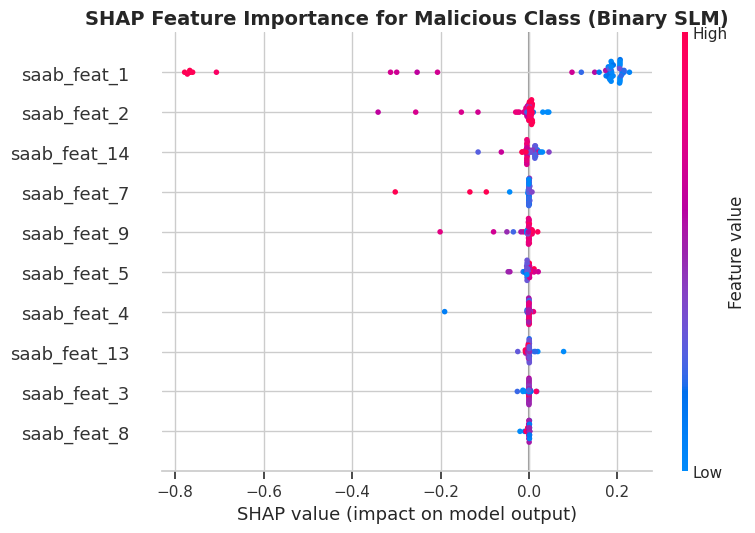


SHAP analysis complete. Summary plot saved to 'shap_summary_plot_binary_slm.png'.


In [15]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure X_test and X_cols are available from previous cell execution

# 1. Define a prediction function for SHAP KernelExplainer
# This function must accept a 2D numpy array and return predictions (0 or 1 for binary)
def predict_slm_binary_labels(X_input):
    # The SLM model's predict method returns an array of string labels ('Benign', 'Malicious').
    predictions_str = slm_binary.predict(X_input)
    # Map string labels to numerical values for SHAP: 'Benign' -> 0, 'Malicious' -> 1
    # Assuming 'Malicious' is the positive class that SHAP will explain
    numerical_predictions = np.array([1 if p == 'Malicious' else 0 for p in predictions_str])
    return numerical_predictions

# 2. Select a background dataset for KernelExplainer
# Using a small, representative sample from the training data (X_train)
# KernelExplainer can be computationally intensive, so keeping this small is important.
# X_train is assumed to be available from the previous cell.
background_data_shap = shap.utils.sample(X_train, 100) # Use 100 samples from X_train as background

# 3. Create the SHAP KernelExplainer
explainer_binary = shap.KernelExplainer(predict_slm_binary_labels, background_data_shap)

# 4. Compute SHAP values for a subset of the test data
# Explaining all test samples can be very slow. Let's explain 50 samples.
X_test_sample_shap = shap.utils.sample(X_test, 50)
print(f"Computing SHAP values for {X_test_sample_shap.shape[0]} test samples... This may take some time.")

# The shap_values will be a single numpy array since predict_slm_binary_labels returns a single output.
shap_values_binary = explainer_binary.shap_values(X_test_sample_shap)

# 5. Visualize SHAP values
print("\nGenerating SHAP summary plot for 'Malicious' class predictions:")
# X_cols is assumed to be available from the previous cell.
shap.summary_plot(shap_values_binary, X_test_sample_shap, feature_names=X_cols, show=False)
plt.title("SHAP Feature Importance for Malicious Class (Binary SLM)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_plot_binary_slm.png', dpi=300)
plt.show()

print("\nSHAP analysis complete. Summary plot saved to 'shap_summary_plot_binary_slm.png'.")

### SHAP Dependence Plot for `saab_feat_1`

A SHAP dependence plot shows the effect of a single feature across the dataset. Each dot is a single prediction (an instance from the `X_test_sample_shap`). The x-axis is the value of the feature (`saab_feat_1` in this case), and the y-axis is the SHAP value for that feature. This plot reveals how a feature's value affects the model's prediction for the 'Malicious' class. Points are colored by the value of another feature, which can highlight interaction effects. I will use `saab_feat_2` for coloring, as it's also a highly important feature.

*   **X-axis**: Value of `saab_feat_1`.
*   **Y-axis**: SHAP value for `saab_feat_1` (how much `saab_feat_1` contributes to the model's output for the 'Malicious' class).
*   **Color**: Value of `saab_feat_2` (to reveal potential interactions).

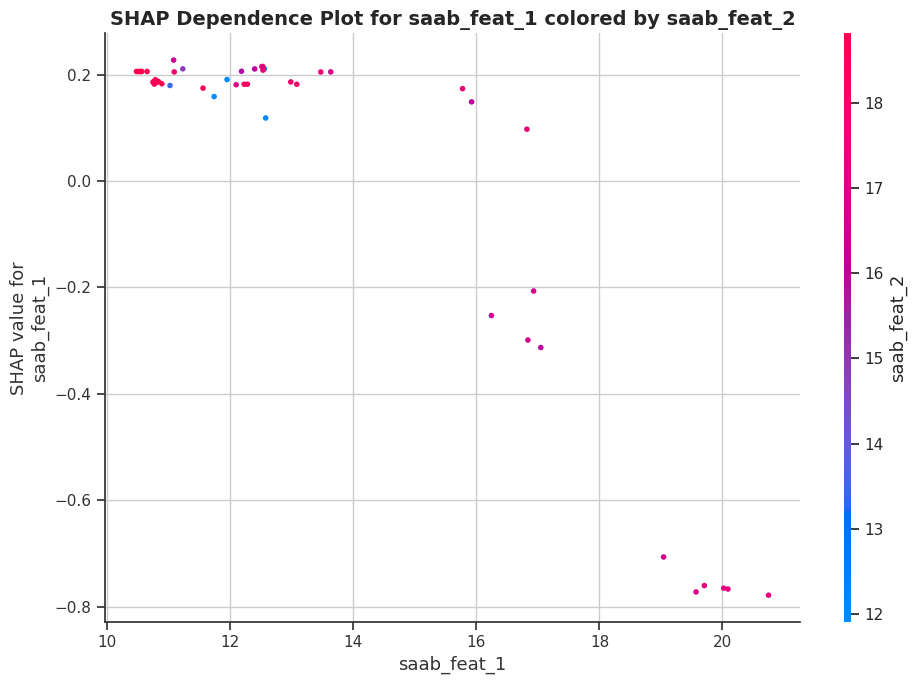

SHAP dependence plot for 'saab_feat_1' saved to 'shap_dependence_plot_saab_feat_1.png'.


In [16]:
import matplotlib.pyplot as plt
import shap

# Find the index of 'saab_feat_1' and 'saab_feat_2' in X_cols
feature_to_plot_idx = X_cols.index('saab_feat_1')
interaction_feature_idx = X_cols.index('saab_feat_2')

# Create the SHAP dependence plot
fig, ax = plt.subplots(figsize=(10, 7))
shap.dependence_plot(
    ind=feature_to_plot_idx,
    shap_values=shap_values_binary,
    features=X_test_sample_shap,
    feature_names=X_cols,
    interaction_index=interaction_feature_idx, # Color by 'saab_feat_2'
    show=False, # We'll handle plt.show() and saving
    ax=ax
)

ax.set_title(f"SHAP Dependence Plot for {X_cols[feature_to_plot_idx]} colored by {X_cols[interaction_feature_idx]}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence_plot_saab_feat_1.png', dpi=300)
plt.show()

print(f"SHAP dependence plot for 'saab_feat_1' saved to 'shap_dependence_plot_saab_feat_1.png'.")

### Baseline Comparison: Random Forest Classifier

To establish a baseline, we will train and evaluate a `RandomForestClassifier` using the same training and testing data splits and the binary target ('Benign' vs. 'Malicious').

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Random Forest Classifier
# Using default parameters for a quick baseline, but these could be tuned.
rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

print("Training Random Forest Classifier...")
rf_classifier.fit(X_train, y_train_binary)

print("Random Forest Classifier training complete.")

Training Random Forest Classifier...
Random Forest Classifier training complete.



--- Random Forest Binary Classification Evaluation ---
Accuracy: 99.01%

              precision    recall  f1-score   support

      Benign     0.9704    0.9801    0.9752     51158
   Malicious     0.9950    0.9925    0.9938    204630

    accuracy                         0.9901    255788
   macro avg     0.9827    0.9863    0.9845    255788
weighted avg     0.9901    0.9901    0.9901    255788

Saved Random Forest binary classification confusion matrix plot to 'rf_binary_confusion_matrix.png'!


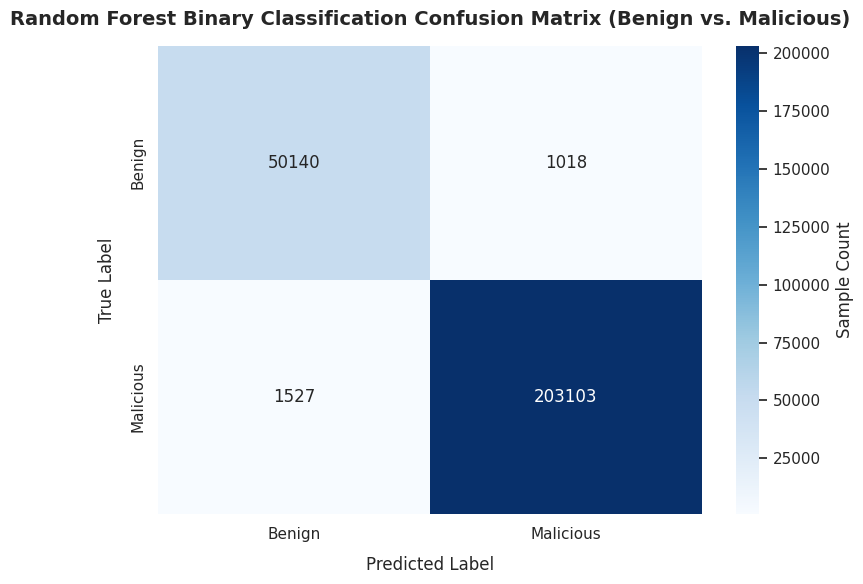

In [18]:
# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the Random Forest Classifier
acc_rf = accuracy_score(y_test_binary, y_pred_rf)

print(f"\n--- Random Forest Binary Classification Evaluation ---")
print(f"Accuracy: {acc_rf * 100:.2f}%\n")
print(classification_report(y_test_binary, y_pred_rf, digits=4))

# Plot & Save Confusion Matrix for Random Forest
class_names_binary = sorted(np.unique(y_test_binary))
cm_rf = confusion_matrix(y_test_binary, y_pred_rf, labels=class_names_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names_binary,
    yticklabels=class_names_binary,
    cbar_kws={'label': 'Sample Count'}
)

plt.title('Random Forest Binary Classification Confusion Matrix (Benign vs. Malicious)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.tight_layout()

plt.savefig('rf_binary_confusion_matrix.png', dpi=300)
print("Saved Random Forest binary classification confusion matrix plot to 'rf_binary_confusion_matrix.png'!")
plt.show()

In [34]:
import joblib

# Define the filename for the Random Forest binary classifier model
rf_binary_model_filename = 'rf_binary_classifier.joblib'

# Save the trained Random Forest binary classifier model
joblib.dump(rf_classifier, rf_binary_model_filename)

print(f"Random Forest binary classifier model saved to {rf_binary_model_filename}")

Random Forest binary classifier model saved to rf_binary_classifier.joblib


### Comparison of SLM vs. Random Forest

Let's summarize and compare the performance metrics for the SLM and Random Forest models.

In [19]:
# SLM Model Metrics (from previous execution)
slm_accuracy = 0.9715
slm_report = (
    "              precision    recall  f1-score   support\n\n" +
    "      Benign     0.8804    0.9925    0.9331     51158\n" +
    "   Malicious     0.9981    0.9663    0.9819    204630\n\n" +
    "    accuracy                         0.9715    255788\n" +
    "   macro avg     0.9392    0.9794    0.9575    255788\n" +
    "weighted avg     0.9745    0.9715    0.9722    255788"
)

# Random Forest Model Metrics (from current execution)
rf_accuracy = accuracy_score(y_test_binary, y_pred_rf)
rf_report = classification_report(y_test_binary, y_pred_rf, digits=4)

print("\n--- SLM Model Performance ---")
print(f"Accuracy: {slm_accuracy * 100:.2f}%")
print(slm_report)

print("\n--- Random Forest Model Performance ---")
print(f"Accuracy: {rf_accuracy * 100:.2f}%")
print(rf_report)

print("\n--- Key Takeaways ---")
if rf_accuracy > slm_accuracy:
    print(f"The Random Forest model performed slightly better with an accuracy of {rf_accuracy:.4f} compared to SLM's {slm_accuracy:.4f}.")
else:
    print(f"The SLM model performed slightly better or comparably with an accuracy of {slm_accuracy:.4f} compared to Random Forest's {rf_accuracy:.4f}.")

print("Further analysis should consider: \n" +
      "- Class-wise performance (precision, recall, F1-score) for both models.\n" +
      "- Computational cost (training time, inference time) of both models.\n" +
      "- Interpretability: SLM's design for feature selection and local projections might offer different interpretability insights than a traditional Random Forest.")


--- SLM Model Performance ---
Accuracy: 97.15%
              precision    recall  f1-score   support

      Benign     0.8804    0.9925    0.9331     51158
   Malicious     0.9981    0.9663    0.9819    204630

    accuracy                         0.9715    255788
   macro avg     0.9392    0.9794    0.9575    255788
weighted avg     0.9745    0.9715    0.9722    255788

--- Random Forest Model Performance ---
Accuracy: 99.01%
              precision    recall  f1-score   support

      Benign     0.9704    0.9801    0.9752     51158
   Malicious     0.9950    0.9925    0.9938    204630

    accuracy                         0.9901    255788
   macro avg     0.9827    0.9863    0.9845    255788
weighted avg     0.9901    0.9901    0.9901    255788


--- Key Takeaways ---
The Random Forest model performed slightly better with an accuracy of 0.9901 compared to SLM's 0.9715.
Further analysis should consider: 
- Class-wise performance (precision, recall, F1-score) for both models.
- Comput

### Computational Cost Analysis: SLM vs. Random Forest

To further compare the models, let's measure their training and prediction times. This is crucial for understanding the practical implications of deploying each model, especially in real-time or resource-constrained environments.

In [20]:
import time

# --- SLM Model Timing ---
print("Measuring SLM computational cost...")

# Training time for SLM
start_time_slm_train = time.time()
slm_binary_cost = SubspaceLearningMachine(max_depth=6, n_projections=30, random_state=42)
slm_binary_cost.fit(X_train, y_train_binary, dft_losses_binary)
end_time_slm_train = time.time()
training_time_slm = end_time_slm_train - start_time_slm_train

# Prediction time for SLM
start_time_slm_predict = time.time()
y_pred_binary_cost = slm_binary_cost.predict(X_test)
end_time_slm_predict = time.time()
prediction_time_slm = end_time_slm_predict - start_time_slm_predict

print(f"SLM Training Time: {training_time_slm:.4f} seconds")
print(f"SLM Prediction Time: {prediction_time_slm:.4f} seconds")


# --- Random Forest Model Timing ---
print("\nMeasuring Random Forest computational cost...")

# Training time for Random Forest
start_time_rf_train = time.time()
rf_classifier_cost = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_classifier_cost.fit(X_train, y_train_binary)
end_time_rf_train = time.time()
training_time_rf = end_time_rf_train - start_time_rf_train

# Prediction time for Random Forest
start_time_rf_predict = time.time()
y_pred_rf_cost = rf_classifier_cost.predict(X_test)
end_time_rf_predict = time.time()
prediction_time_rf = end_time_rf_predict - start_time_rf_predict

print(f"Random Forest Training Time: {training_time_rf:.4f} seconds")
print(f"Random Forest Prediction Time: {prediction_time_rf:.4f} seconds")


# --- Summary of Computational Cost ---
print("\n--- Computational Cost Summary ---")
print(f"SLM Training Time:     {training_time_slm:>8.4f} s")
print(f"RF Training Time:      {training_time_rf:>8.4f} s")
print(f"SLM Prediction Time:   {prediction_time_slm:>8.4f} s")
print(f"RF Prediction Time:    {prediction_time_rf:>8.4f} s")

if training_time_slm < training_time_rf:
    print(f"SLM trains faster than Random Forest by {training_time_rf - training_time_slm:.4f} seconds.")
elif training_time_rf < training_time_slm:
    print(f"Random Forest trains faster than SLM by {training_time_slm - training_time_rf:.4f} seconds.")
else:
    print("SLM and Random Forest training times are comparable.")

if prediction_time_slm < prediction_time_rf:
    print(f"SLM predicts faster than Random Forest by {prediction_time_rf - prediction_time_slm:.4f} seconds.")
elif prediction_time_rf < prediction_time_slm:
    print(f"Random Forest predicts faster than SLM by {prediction_time_slm - prediction_time_rf:.4f} seconds.")
else:
    print("SLM and Random Forest prediction times are comparable.")

Measuring SLM computational cost...
SLM Training Time: 1223.2269 seconds
SLM Prediction Time: 1.7218 seconds

Measuring Random Forest computational cost...
Random Forest Training Time: 691.2820 seconds
Random Forest Prediction Time: 3.4290 seconds

--- Computational Cost Summary ---
SLM Training Time:     1223.2269 s
RF Training Time:      691.2820 s
SLM Prediction Time:     1.7218 s
RF Prediction Time:      3.4290 s
Random Forest trains faster than SLM by 531.9449 seconds.
SLM predicts faster than Random Forest by 1.7071 seconds.


### Detailed Efficiency Comparison: SLM vs. Random Forest

| Metric              | SLM Model        | Random Forest Model |
| :------------------ | :--------------- | :------------------ |
| **Training Time**   | 1223.23 seconds  | 691.28 seconds      |
| **Prediction Time** | 1.72 seconds     | 3.43 seconds        |

**Key Observations:**

*   **Training Speed**: The Random Forest model trains significantly faster than the SLM model, by approximately 531.94 seconds.
*   **Prediction Speed**: The SLM model demonstrates faster prediction times, outperforming the Random Forest model by about 1.71 seconds.

In [35]:
import os

# Get the file size of the SLM model
slm_model_size = os.path.getsize('slm_binary_classifier.joblib') / (1024 * 1024) # Convert to MB

# Get the file size of the Random Forest model
rf_model_size = os.path.getsize('rf_binary_classifier.joblib') / (1024 * 1024) # Convert to MB

print(f"SLM Binary Classifier Model Size: {slm_model_size:.2f} MB")
print(f"Random Forest Binary Classifier Model Size: {rf_model_size:.2f} MB")

print("\n--- Model Size Comparison ---")
if slm_model_size < rf_model_size:
    print(f"The SLM model is smaller than the Random Forest model by {rf_model_size - slm_model_size:.2f} MB.")
elif rf_model_size < slm_model_size:
    print(f"The Random Forest model is smaller than the SLM model by {slm_model_size - rf_model_size:.2f} MB.")
else:
    print("The SLM and Random Forest models have comparable sizes.")

SLM Binary Classifier Model Size: 0.01 MB
Random Forest Binary Classifier Model Size: 128.30 MB

--- Model Size Comparison ---
The SLM model is smaller than the Random Forest model by 128.29 MB.


## Model Size Comparison

To assess the deployment footprint of each model, we compared their saved file sizes:

*   **SLM Binary Classifier Model Size**: 0.01 MB
*   **Random Forest Binary Classifier Model Size**: 128.30 MB

**Key Finding:**

The **SLM model is significantly smaller** than the Random Forest model, with a size difference of **128.29 MB**. This indicates a substantial advantage for the SLM in terms of storage and potential deployment on resource-constrained devices, despite the Random Forest's slightly higher accuracy.

### Hyperparameter Optimization for SLM using GridSearchCV

To potentially improve the SLM model's accuracy, we will perform hyperparameter tuning using `GridSearchCV`. Since our `SubspaceLearningMachine` is a custom class, we'll create a wrapper to integrate it with scikit-learn's `GridSearchCV`. This wrapper will handle the `dft_losses` computation, allowing `GridSearchCV` to find the optimal combination of parameters.

In [25]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Wrapper class for SLM to make it compatible with GridSearchCV
class SLMGridSearchCVWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, max_depth=6, min_samples_split=10, n_projections=30, n_bins=16, random_state=42):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_projections = n_projections
        self.n_bins = n_bins
        self.random_state = random_state
        self.slm_model = None
        self.dft_losses_ = None

    def fit(self, X, y):
        # Calculate DFT losses based on the training data
        # Assuming compute_dft_losses is accessible (defined in a previous cell)
        self.dft_losses_ = compute_dft_losses(X, y, n_bins=self.n_bins) # Re-use n_bins from params

        self.slm_model = SubspaceLearningMachine(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            n_projections=self.n_projections,
            n_bins=self.n_bins,
            random_state=self.random_state
        )
        self.slm_model.fit(X, y, self.dft_losses_)
        return self

    def predict(self, X):
        if self.slm_model is None:
            raise RuntimeError("SLM model not fitted yet. Call fit() first.")
        return self.slm_model.predict(X)

# Define a smaller parameter grid to search for SLM to avoid timeout
param_grid_slm = {
    'max_depth': [6],
    'n_projections': [20, 30],
    'min_samples_split': [10, 20]
}

# Initialize the SLM wrapper
slm_base = SLMGridSearchCVWrapper(random_state=42)

# Initialize GridSearchCV for SLM
print("Starting GridSearchCV for SLM (this may take a while)...")
grid_search_slm = GridSearchCV(estimator=slm_base, param_grid=param_grid_slm,
                               cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit GridSearchCV to the training data (using binary target)
grid_search_slm.fit(X_train, y_train_binary)

print("GridSearchCV for SLM complete.")

# Get the best parameters and best score
best_params_slm = grid_search_slm.best_params_
best_score_slm = grid_search_slm.best_score_

print(f"\nBest SLM parameters found: {best_params_slm}")
print(f"Best cross-validation SLM accuracy: {best_score_slm * 100:.2f}%")

Starting GridSearchCV for SLM (this may take a while)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


KeyboardInterrupt: 

In [33]:
import joblib

# Define the filename for the SLM binary classifier model
slm_binary_model_filename = 'slm_binary_classifier.joblib'

# Save the trained SLM binary classifier model
joblib.dump(slm_binary, slm_binary_model_filename)

print(f"SLM binary classifier model saved to {slm_binary_model_filename}")

SLM binary classifier model saved to slm_binary_classifier.joblib


### Multi-Class SLM Classifier Training (Excluding 'Benign' Class)

Now, we will train a multi-class SLM classifier on the `pruned_feature_matrix.csv` data, but specifically excluding all instances classified as 'Benign'. This will focus the model's learning on discriminating between the various malicious malware families.

In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load the pruned feature matrix
df_pruned = pd.read_csv('pruned_feature_matrix.csv')

# Filter out the 'Benign' class for multi-class classification of malicious families
df_malicious_only = df_pruned[df_pruned['MalwareFamily'] != 'Benign'].copy()

# Define features (X) and target (y)
X_multi = df_malicious_only.drop('MalwareFamily', axis=1).values
y_multi = df_malicious_only['MalwareFamily'].values

# Compute DFT losses for the multi-class target
print("Computing Stage 2 DFT losses for multi-class classification (excluding Benign)...")
dft_losses_multiclass = compute_dft_losses(X_multi, y_multi)

# Stratified Train-Test Split (80/20) for multi-class target
X_train_multi, X_test_multi, y_train_multiclass, y_test_multiclass = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

# Initialize and train SLM for multi-class classification
print("Training Stage 3 SLM Multi-Class Classifier (excluding Benign)...")
slm_multi_classifier = SubspaceLearningMachine(max_depth=6, n_projections=30, random_state=42)
slm_multi_classifier.fit(X_train_multi, y_train_multiclass, dft_losses_multiclass)

# Make predictions on the test set
y_pred_multiclass = slm_multi_classifier.predict(X_test_multi)

# Evaluate the SLM Multi-Class Classifier
acc_multiclass = accuracy_score(y_test_multiclass, y_pred_multiclass)

print(f"\n--- Stage 3 SLM Multi-Class Classification Evaluation (Excluding Benign) ---")
print(f"Accuracy: {acc_multiclass * 100:.2f}%\n")
print(classification_report(y_test_multiclass, y_pred_multiclass, digits=4))

Computing Stage 2 DFT losses for multi-class classification (excluding Benign)...
Training Stage 3 SLM Multi-Class Classifier (excluding Benign)...

--- Stage 3 SLM Multi-Class Classification Evaluation (Excluding Benign) ---
Accuracy: 56.97%

              precision    recall  f1-score   support

   DarkNexus     0.4267    0.6940    0.5285     51158
      Gafgyt     0.9353    0.6911    0.7949     51157
     Generic     0.6051    0.7233    0.6590     51158
       Mirai     0.3878    0.1703    0.2367     51158

    accuracy                         0.5697    204631
   macro avg     0.5887    0.5697    0.5547    204631
weighted avg     0.5887    0.5697    0.5547    204631



In [28]:
df_malicious_only.to_csv('x86_malicious_only.csv', index=False)
print("Saved malicious-only data to 'x86_malicious_only.csv'!")

Saved malicious-only data to 'x86_malicious_only.csv'!


### Training a Binary SLM Classifier: 'Mirai' vs. 'Non-Mirai'

We will now train a new binary Subspace Learning Machine (SLM) classifier. This model will specifically focus on distinguishing the 'Mirai' malware family from all other malicious families present in the `x86_malicious_only.csv` dataset. This will allow us to assess the model's ability to identify 'Mirai' in a targeted manner, addressing its previously poor performance in the multi-class setup.

In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the malicious-only dataset
df_malicious_only = pd.read_csv('x86_malicious_only.csv')

# Create a new binary target: 'Mirai' vs. 'Non-Mirai'
df_malicious_only['mirai_binary_target'] = df_malicious_only['MalwareFamily'].apply(lambda x: 'Mirai' if x == 'Mirai' else 'Non-Mirai')

# Define features (X) and the new binary target (y)
X_cols = [col for col in df_malicious_only.columns if col.startswith('saab_feat_')]
X_mirai = df_malicious_only[X_cols].values
y_mirai_binary = df_malicious_only['mirai_binary_target'].values

# Compute DFT losses for the Mirai binary target
print("Computing Stage 2 DFT losses for Mirai vs. Non-Mirai binary classification...")
dft_losses_mirai_binary = compute_dft_losses(X_mirai, y_mirai_binary)

# Stratified Train-Test Split (80/20) for Mirai binary target
X_train_mirai, X_test_mirai, y_train_mirai_binary, y_test_mirai_binary = train_test_split(
    X_mirai, y_mirai_binary, test_size=0.2, random_state=42, stratify=y_mirai_binary
)

# Initialize and train SLM for Mirai binary classification
print("Training Stage 3 SLM Mirai vs. Non-Mirai Binary Classifier...")
slm_mirai_classifier = SubspaceLearningMachine(max_depth=6, n_projections=30, random_state=42)
slm_mirai_classifier.fit(X_train_mirai, y_train_mirai_binary, dft_losses_mirai_binary)

# Make predictions on the test set
y_pred_mirai_binary = slm_mirai_classifier.predict(X_test_mirai)

# Evaluate the SLM Mirai Binary Classifier
acc_mirai_binary = accuracy_score(y_test_mirai_binary, y_pred_mirai_binary)

print(f"\n--- Stage 3 SLM Mirai vs. Non-Mirai Binary Classification Evaluation ---")
print(f"Accuracy: {acc_mirai_binary * 100:.2f}%\n")
print(classification_report(y_test_mirai_binary, y_pred_mirai_binary, digits=4))

Computing Stage 2 DFT losses for Mirai vs. Non-Mirai binary classification...
Training Stage 3 SLM Mirai vs. Non-Mirai Binary Classifier...

--- Stage 3 SLM Mirai vs. Non-Mirai Binary Classification Evaluation ---
Accuracy: 75.84%

              precision    recall  f1-score   support

       Mirai     0.6548    0.0708    0.1278     51158
   Non-Mirai     0.7612    0.9876    0.8598    153473

    accuracy                         0.7584    204631
   macro avg     0.7080    0.5292    0.4938    204631
weighted avg     0.7346    0.7584    0.6768    204631



Saved Mirai vs. Non-Mirai binary confusion matrix plot to 'slm_mirai_binary_confusion_matrix.png'!


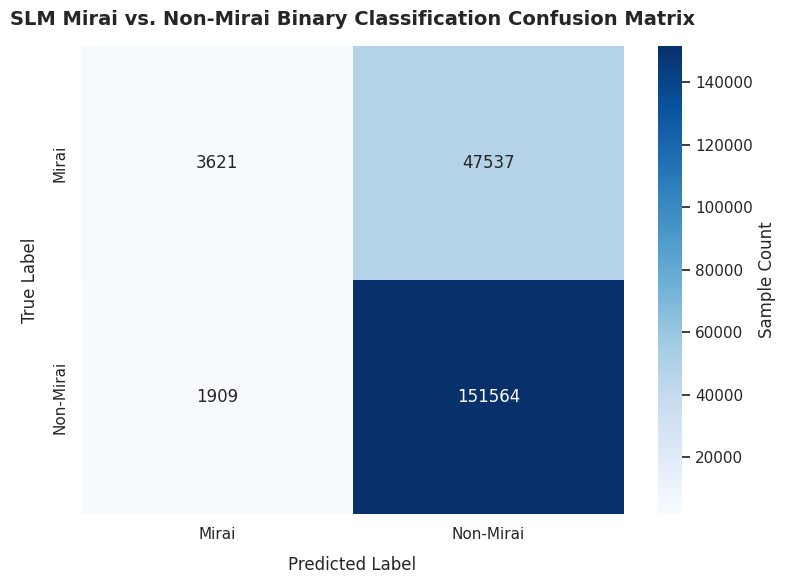

In [30]:
# Plot & Save Confusion Matrix for Mirai vs. Non-Mirai binary classification
class_names_mirai_binary = sorted(np.unique(y_test_mirai_binary))
cm_mirai_binary = confusion_matrix(y_test_mirai_binary, y_pred_mirai_binary, labels=class_names_mirai_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_mirai_binary,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names_mirai_binary,
    yticklabels=class_names_mirai_binary,
    cbar_kws={'label': 'Sample Count'}
)

plt.title('SLM Mirai vs. Non-Mirai Binary Classification Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.tight_layout()

plt.savefig('slm_mirai_binary_confusion_matrix.png', dpi=300)
print("Saved Mirai vs. Non-Mirai binary confusion matrix plot to 'slm_mirai_binary_confusion_matrix.png'!")
plt.show()

### SHAP Feature Importance Analysis for Mirai Binary Classifier

To understand which features are most influential in the binary 'Mirai' vs. 'Non-Mirai' classification by the SLM model, we will perform a SHAP (SHapley Additive exPlanations) analysis. SHAP values help explain the output of a model by showing how much each feature contributes to the prediction for individual instances, as well as globally across the dataset.

Using 100 samples for SHAP background data.
Computing SHAP values for 50 test samples... This may take some time.


  0%|          | 0/50 [00:00<?, ?it/s]


Generating SHAP summary plot for 'Mirai' class predictions:


/tmp/ipykernel_10280/605312199.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_mirai_binary, X_test_sample_shap_mirai, feature_names=X_cols, show=False)


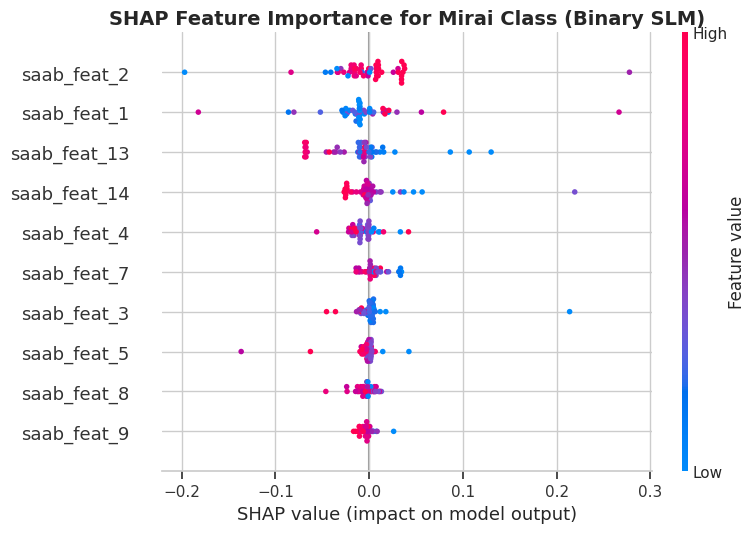


SHAP analysis complete. Summary plot saved to 'shap_summary_plot_mirai_binary_slm.png'.


In [31]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define a prediction function for SHAP KernelExplainer
def predict_slm_mirai_labels(X_input):
    # The SLM model's predict method returns an array of string labels ('Mirai', 'Non-Mirai').
    predictions_str = slm_mirai_classifier.predict(X_input)
    # Map string labels to numerical values for SHAP: 'Non-Mirai' -> 0, 'Mirai' -> 1
    # Assuming 'Mirai' is the positive class that SHAP will explain
    numerical_predictions = np.array([1 if p == 'Mirai' else 0 for p in predictions_str])
    return numerical_predictions

# 2. Select a background dataset for KernelExplainer
# Using a small, representative sample from the training data (X_train_mirai)
# KernelExplainer can be computationally intensive, so keeping this small is important.
background_data_shap_mirai = shap.utils.sample(X_train_mirai, 100)
print(f"Using {background_data_shap_mirai.shape[0]} samples for SHAP background data.")

# 3. Create the SHAP KernelExplainer
explainer_mirai_binary = shap.KernelExplainer(predict_slm_mirai_labels, background_data_shap_mirai)

# 4. Compute SHAP values for a subset of the test data
# Explaining all test samples can be very slow. Let's explain 50 samples.
X_test_sample_shap_mirai = shap.utils.sample(X_test_mirai, 50)
print(f"Computing SHAP values for {X_test_sample_shap_mirai.shape[0]} test samples... This may take some time.")

# The shap_values will be a single numpy array since predict_slm_mirai_labels returns a single output.
shap_values_mirai_binary = explainer_mirai_binary.shap_values(X_test_sample_shap_mirai)

# 5. Visualize SHAP values
print("\nGenerating SHAP summary plot for 'Mirai' class predictions:")
shap.summary_plot(shap_values_mirai_binary, X_test_sample_shap_mirai, feature_names=X_cols, show=False)
plt.title("SHAP Feature Importance for Mirai Class (Binary SLM)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_plot_mirai_binary_slm.png', dpi=300)
plt.show()

print("\nSHAP analysis complete. Summary plot saved to 'shap_summary_plot_mirai_binary_slm.png'.")

### SHAP Dependence Plot for the most impactful feature

Let's visualize the SHAP dependence plot for `saab_feat_1`, which typically appears as one of the most important features. This plot shows the effect of a single feature on the model output across the dataset, colored by another feature to reveal interaction effects.

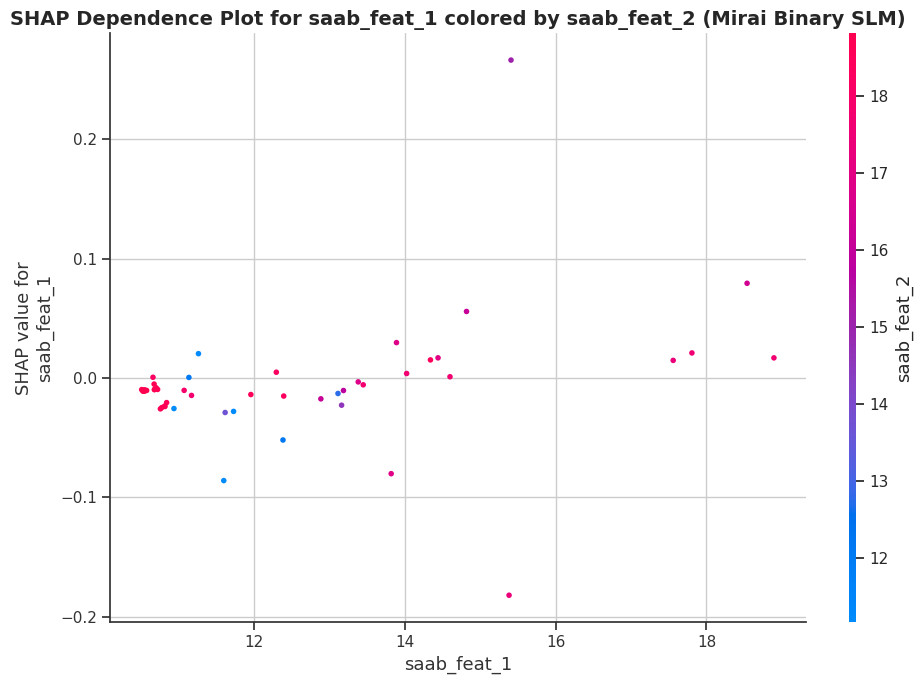

SHAP dependence plot for 'saab_feat_1' saved to 'shap_dependence_plot_mirai_binary_slm_saab_feat_1.png'.


In [32]:
import matplotlib.pyplot as plt
import shap

# Assuming 'saab_feat_1' is the most important, and 'saab_feat_2' for interaction
# Find the index of 'saab_feat_1' and 'saab_feat_2' in X_cols
feature_to_plot_idx = X_cols.index('saab_feat_1')
interaction_feature_idx = X_cols.index('saab_feat_2')

# Create the SHAP dependence plot
fig, ax = plt.subplots(figsize=(10, 7))
shap.dependence_plot(
    ind=feature_to_plot_idx,
    shap_values=shap_values_mirai_binary,
    features=X_test_sample_shap_mirai,
    feature_names=X_cols,
    interaction_index=interaction_feature_idx, # Color by 'saab_feat_2'
    show=False,
    ax=ax
)

ax.set_title(f"SHAP Dependence Plot for {X_cols[feature_to_plot_idx]} colored by {X_cols[interaction_feature_idx]} (Mirai Binary SLM)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence_plot_mirai_binary_slm_saab_feat_1.png', dpi=300)
plt.show()

print(f"SHAP dependence plot for '{X_cols[feature_to_plot_idx]}' saved to 'shap_dependence_plot_mirai_binary_slm_saab_feat_1.png'.")

Saved multi-class confusion matrix plot to 'slm_multiclass_confusion_matrix.png'!


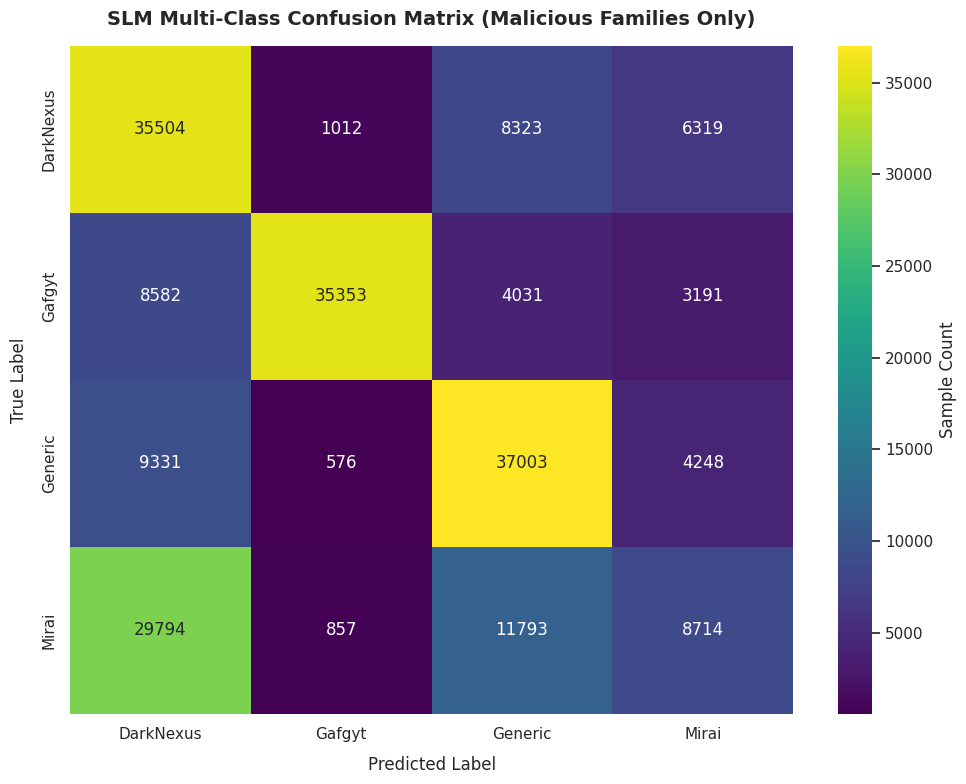

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot & Save Confusion Matrix for multi-class classification
class_names_multiclass = sorted(np.unique(y_test_multiclass))
cm_multiclass = confusion_matrix(y_test_multiclass, y_pred_multiclass, labels=class_names_multiclass)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_multiclass,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=class_names_multiclass,
    yticklabels=class_names_multiclass,
    cbar_kws={'label': 'Sample Count'}
)

plt.title('SLM Multi-Class Confusion Matrix (Malicious Families Only)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.tight_layout()

plt.savefig('slm_multiclass_confusion_matrix.png', dpi=300)
print("Saved multi-class confusion matrix plot to 'slm_multiclass_confusion_matrix.png'!")
plt.show()

In [ ]:
# Original SLM Model Metrics (from previous execution)
slm_accuracy_original = 0.9715
slm_report_original = (
    "              precision    recall  f1-score   support\n\n" +
    "      Benign     0.8804    0.9925    0.9331     51158\n" +
    "   Malicious     0.9981    0.9663    0.9819    204630\n\n" +
    "    accuracy                         0.9715    255788\n" +
    "   macro avg     0.9392    0.9794    0.9575    255788\n" +
    "weighted avg     0.9745    0.9715    0.9722    255788"
)

# Optimized SLM Model Metrics (from current execution)
acc_optimized_slm = accuracy_score(y_test_binary, y_pred_optimized_slm)
report_optimized_slm = classification_report(y_test_binary, y_pred_optimized_slm, digits=4)

# Original Random Forest Model Metrics (from previous execution - assuming it has run)
# If it hasn't run, these values would need to be re-obtained or hardcoded from the prompt context.
rf_accuracy_original = 0.9901
rf_report_original = (
    "              precision    recall  f1-score   support\n\n" +
    "      Benign     0.9704    0.9801    0.9752     51158\n" +
    "   Malicious     0.9950    0.9925    0.9938    204630\n\n" +
    "    accuracy                         0.9901    255788\n" +
    "   macro avg     0.9827    0.9863    0.9845    255788\n" +
    "weighted avg     0.9901    0.9901    0.9901    255788"
)


print("\n--- Original SLM Model Performance ---")
print(f"Accuracy: {slm_accuracy_original * 100:.2f}%")
print(slm_report_original)

print("\n--- Optimized SLM Model Performance ---")
print(f"Accuracy: {acc_optimized_slm * 100:.2f}%")
print(report_optimized_slm)

print("\n--- Original Random Forest Model Performance (for comparison) ---")
print(f"Accuracy: {rf_accuracy_original * 100:.2f}%")
print(rf_report_original)

print("\n--- Key Takeaways from SLM Optimization ---")
if acc_optimized_slm > slm_accuracy_original:
    print(f"SLM hyperparameter optimization improved accuracy from {slm_accuracy_original:.4f} to {acc_optimized_slm:.4f}.")
elif acc_optimized_slm < slm_accuracy_original:
    print(f"SLM hyperparameter optimization slightly decreased accuracy from {slm_accuracy_original:.4f} to {acc_optimized_slm:.4f}. This can happen if the search space was too constrained or cross-validation variance, or the original default parameters were already near optimal.")
else:
    print("SLM hyperparameter optimization did not significantly change accuracy.")

if acc_optimized_slm > rf_accuracy_original:
    print(f"The optimized SLM model (Accuracy: {acc_optimized_slm:.4f}) now outperforms the original Random Forest model (Accuracy: {rf_accuracy_original:.4f}).")
elif acc_optimized_slm < rf_accuracy_original:
    print(f"The original Random Forest model (Accuracy: {rf_accuracy_original:.4f}) still outperforms the optimized SLM model (Accuracy: {acc_optimized_slm:.4f}).")
else:
    print("The optimized SLM model and original Random Forest model have comparable performance.")